# SIA-GAN: Scrambling Inversion Attack Using Generative Adversarial Network: quick start

Official implementation of the IEEE Access 2021 paper by Koki Madono, Masayuki Tanaka, Masaki Onishi and Tetsuji Ogawa
([paper, open access](https://doi.org/10.1109/ACCESS.2021.3112684), [code](https://github.com/MADONOKOUKI/SIA-GAN),
[project page](https://madonokouki.github.io/projects/siagan/)).

This notebook runs on a CPU in under a minute. It
1. scrambles an image with the five schemes attacked in the paper (PE, random PE, LE, ELE, EtC), and
2. builds SIA-GAN (adaptation network + feature decoder against a discriminator) and runs a few training steps,
   an inversion and an evaluation on synthetic data.

In [1]:
# Install the package when running on Google Colab (locally: `pip install -e .` in the repository).
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/MADONOKOUKI/SIA-GAN"], check=True)

## 1. The scrambling schemes

A 32x32 image (CIFAR size) is scrambled with the schemes of Tables 1-3, using the keys of the original experiments
(`key="paper"`, the default; pass an integer seed for a new key). **PE** inverts values and shuffles the colour
channels of individual pixels, **random PE** inverts half of the values with a new random key for every image,
**LE** shuffles and inverts the 4-bit halves of the pixel values with one key for all 4x4 blocks, **ELE** uses a
different key per block and shuffles the block locations, and **EtC** rotates, flips, inverts and colour-shuffles
every block and shuffles the block locations. The paper finds that SIA-GAN recovers images scrambled without block
shuffling, while ELE and EtC resist the attack.

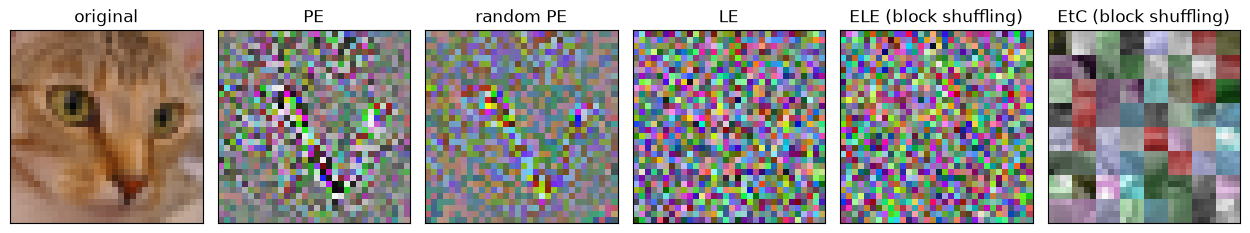

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data
import siagan

cat = Image.fromarray(data.chelsea()[:, 75:375]).resize((32, 32), Image.BICUBIC)  # CIFAR-sized cat
img = np.asarray(cat)

schemes = {"PE": siagan.PE(), "random PE": siagan.RandomPE(seed=0), "LE": siagan.LE(),
           "ELE": siagan.ELE(), "EtC": siagan.EtC()}
fig, axes = plt.subplots(1, 6, figsize=(12.6, 2.6))
axes[0].imshow(img); axes[0].set_title("original")
for ax, (name, scheme) in zip(axes[1:], schemes.items()):
    ax.imshow(scheme(img), interpolation="nearest")
    ax.set_title(name + (" (block shuffling)" if name in ("ELE", "EtC") else ""))
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

Every scheme accepts PIL images, numpy arrays (`HxWxC`, `uint8` or float) and torch tensors (`CxHxW` /
`NxCxHxW`), so it can be used as a torchvision transform. LE, ELE and block shuffling have an exact inverse with the
key; the PE and EtC of the original code duplicate colour channels and cannot be inverted
(`channel_mode="permutation"` gives invertible variants). Random PE keeps no key.

In [3]:
import torch
import torchvision.transforms as T

transform = T.Compose([T.RandomHorizontalFlip(), T.ToTensor(), siagan.ELE()])
x = transform(cat)
print(x.shape, x.dtype, float(x.min()), float(x.max()))
print("LE inverse is exact:", np.array_equal(siagan.LE().inverse(siagan.LE()(img)), img))

torch.Size([3, 32, 32]) torch.float32 0.0 1.0
LE inverse is exact: True


## 2. SIA-GAN

The generator is an **adaptation network** (one spectrally normalised 4x4 convolution + BatchNorm + LeakyReLU per
block and a pixel-shuffle layer, Table 4; 1x1 "blocks" for PE and random PE) followed by a **feature decoder**
(Table 5). A spectrally normalised **discriminator** with self-attention (Table 6) compares its outputs with real
images, and both are trained with the hinge loss (Eqs. 3-4). As in the original code, a ShakeDrop PyramidNet-110
classifier trained on the generated images adds a cross-entropy term. `siagan.SIAGAN()` uses the paper's settings;
here the discriminator is narrowed and the classifier left out so that a few steps run in seconds on a CPU.

In [4]:
torch.manual_seed(0)
x, y = torch.rand(32, 3, 32, 32), torch.randint(0, 10, (32,))    # stand-in for CIFAR-10 (image, label) batches
loader = [(x[i:i + 16], y[i:i + 16]) for i in range(0, 32, 16)]  # each batch: 8 real + 8 scrambled images

attack = siagan.SIAGAN(num_classes=10, discriminator_width=64, classifier=None, device="cpu")
for h in attack.fit(loader, siagan.LE(), epochs=3, log=None):
    print(f"epoch {h['epoch']}: d_loss {h['d_loss']:.3f}  g_adv {h['g_adv']:.3f}")

recovered = attack.reconstruct(siagan.LE()(x[:4]))              # Eq. 5: x = G(scrambled), images in [0, 1]
print("recovered", tuple(recovered.shape))
print(attack.evaluate(loader, siagan.LE(), metrics=("psnr", "ssim")))  # default metrics also include LPIPS

epoch 1: d_loss 1.996  g_adv -0.010
epoch 2: d_loss 2.012  g_adv -0.069
epoch 3: d_loss 2.026  g_adv -0.115
recovered (4, 3, 32, 32)


{'scrambled': {'psnr': 7.768043927778615, 'ssim': 0.1198479829590808}, 'reconstructed': {'psnr': 10.592188536862759, 'ssim': 0.18364025244649337}, 'num_images': 32}


`attack.evaluate(test_loader, scrambler)` reports PSNR, SSIM and LPIPS (AlexNet, as in Table 3; the AlexNet
weights are downloaded on first use) of the scrambled images and of the SIA-GAN reconstructions.

## 3. Reproduce the paper (GPU recommended)

The command-line script lives in the repository (it is not part of the pip package):

```bash
git clone --depth 1 https://github.com/MADONOKOUKI/SIA-GAN
cd SIA-GAN && pip install -e .
python attack.py --scheme le --real-dataset cifar100      # one cell of Table 3 and one column of Table 2
python attack.py --dataset fake --epochs 1 --batch-size 8 --ndf 64 --classifier none --no-lpips   # smoke test
```

`scripts/reproduce_table3.sh` lists the 20 runs of Table 3.